In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from tqdm import tqdm
from wordcloud import WordCloud


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn import metrics
from sklearn.metrics import roc_auc_score,roc_curve,auc,confusion_matrix,classification_report
%matplotlib inline
warnings.filterwarnings("ignore")
from IPython.display import Image,YouTubeVideo,HTML

#KERAS Import
from keras.models import Sequential, Model
from keras.utils import to_categorical,plot_model
from keras.layers import Dense, Activation
from keras.layers import BatchNormalization
from keras.initializers import he_normal
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing import sequence
from keras.layers import Dropout
from keras.layers import Embedding, LSTM, GRU, Flatten, Input, concatenate, Conv1D, GlobalMaxPool1D, SpatialDropout1D, GlobalMaxPooling1D, Bidirectional, GlobalAveragePooling1D, add
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.initializers import Orthogonal
from tensorflow.keras.preprocessing.text import one_hot
from keras.constraints import max_norm
#from tensorboardcolab import TensorBoardColab, TensorBoardColabCallback

#for attention mechanism
from keras import backend as K
from keras.layers import Layer
from keras import initializers, regularizers, constraints, optimizers, layers

2026-05-20 10:23:42.881418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779272623.113265      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779272623.178241      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779272623.698444      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779272623.698493      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779272623.698496      57 computation_placer.cc:177] computation placer alr

In [3]:
import gdown
import pandas as pd

# The raw URL
url = "https://drive.google.com/file/d/1gND_ylSniEH7F7BTqEpS6QEqdg78Clkh/view?usp=sharing"
output_filename = 'df.pkl'

# Use fuzzy=True so gdown strips away the Google HTML warning pages
file_path = gdown.download(url, output_filename, quiet=False, fuzzy=True)

# Read the file now that it is properly saved on disk
df = pd.read_pickle(file_path)
df.head()


Downloading...
From (original): https://drive.google.com/uc?id=1gND_ylSniEH7F7BTqEpS6QEqdg78Clkh
From (redirected): https://drive.google.com/uc?id=1gND_ylSniEH7F7BTqEpS6QEqdg78Clkh&confirm=t&uuid=f1745526-c2c9-4f82-90f5-9e8e050f005b
To: /kaggle/working/df.pkl
100%|██████████| 1.22G/1.22G [00:07<00:00, 165MB/s] 


,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,...,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
0,59848,0.000000,this is so cool it is like would you want your...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
1,59849,0.000000,thank you this would make my life a lot less a...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
2,59852,0.000000,this is such an urgent design problem kudos to...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
3,59855,0.000000,is this something i will be able to install on...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
4,59856,0.893617,haha you guys are a bunch of losers,0.021277,0.0,0.021277,0.87234,0.0,0.0,0.0,...,2006,rejected,0,0,0,1,0,0.0,4,47


In [4]:
# The raw URL
url = "https://drive.google.com/file/d/1YatDph1Ndo-ETR2o_yOnYLlgtdxqrI01/view?usp=sharing"
output_filename = 'test_df.pkl'

# Use fuzzy=True so gdown strips away the Google HTML warning pages
file_path = gdown.download(url, output_filename, quiet=False, fuzzy=True)

# Read the file now that it is properly saved on disk
test_df = pd.read_pickle(file_path)
test_df.head()


Downloading...
From: https://drive.google.com/uc?id=1YatDph1Ndo-ETR2o_yOnYLlgtdxqrI01
To: /kaggle/working/test_df.pkl
100%|██████████| 29.1M/29.1M [00:00<00:00, 86.1MB/s]


,id,comment_text
0,7097320,integrity means that you pay your debts does t...
1,7097321,this is malfeasance by the administrator and t...
2,7097322,rmiller101 spoken like a true elitist but look...
3,7097323,paul thank you for your kind words i do indeed...
4,7097324,sorry you missed high school eisenhower sent t...


In [5]:
identity_columns = ['male', 'female', 'homosexual_gay_or_lesbian', 'christian', 'jewish',
    'muslim', 'black', 'white', 'psychiatric_or_mental_illness']

In [6]:
for column in identity_columns + ['target']:
    df[column] = np.where(df[column] >= 0.5, True, False)

In [7]:
# Target variable as well
y = df['target'].values

In [8]:
train_df, cv_df, y_train, y_cv = train_test_split(df, y, test_size=0.2, random_state=42)

**Recurrent Nueral Network**

Metrics definition

In [9]:
SUBGROUP_AUC = 'subgroup_auc'
BPSN_AUC = 'bpsn_auc'  # stands for background positive, subgroup negative
BNSP_AUC = 'bnsp_auc'  # stands for background negative, subgroup positive
TOXICITY_COLUMN = 'target'

def compute_auc(y_true, y_pred): # helper function which wraps the scikit learn's roc_auc_score such that if subgroup don't have enough data it returns NaN.
    try:
        return metrics.roc_auc_score(y_true, y_pred)
    except ValueError:
        return np.nan

def compute_subgroup_auc(df, subgroup, label, model_name):
    subgroup_examples = df[df[subgroup]]
    return compute_auc(subgroup_examples[label], subgroup_examples[model_name])

def compute_bpsn_auc(df, subgroup, label, model_name): # combine background positive examples and subgroup negative examples
    """Computes the AUC of the within-subgroup negative examples and the background positive examples."""
    subgroup_negative_examples = df[df[subgroup] & ~df[label]]
    non_subgroup_positive_examples = df[~df[subgroup] & df[label]]
    print("\nSubgroup = ",subgroup)
    print("\nsubgroup_negative_examples = ",len(subgroup_negative_examples))
    print("\nnon_subgroup_positive_examples = ",len(non_subgroup_positive_examples))
    examples = pd.concat([
        subgroup_negative_examples,
        non_subgroup_positive_examples
    ])
    return compute_auc(examples[label], examples[model_name])

def compute_bnsp_auc(df, subgroup, label, model_name): # combine background negative examples and subgroup positive examples
    """Computes the AUC of the within-subgroup positive examples and the background negative examples."""
    subgroup_positive_examples = df[df[subgroup] & df[label]]
    non_subgroup_negative_examples = df[~df[subgroup] & ~df[label]]
    print("\nSubgroup = ",subgroup)
    print("\nsubgroup_positive_examples = ",len(subgroup_positive_examples))
    print("\nnon_subgroup_negative_examples = ",len(non_subgroup_negative_examples))
    examples = pd.concat([
        subgroup_positive_examples,
        non_subgroup_negative_examples
    ])
    return compute_auc(examples[label], examples[model_name])

def compute_bias_metrics_for_model(dataset,
                                   subgroups,
                                   model,
                                   label_col,
                                   include_asegs=False): # takes each subgroup and use all the functions
    """Computes per-subgroup metrics for all subgroups and one model."""
    records = []
    for subgroup in subgroups:
        record = {
            'subgroup': subgroup,
            'subgroup_size': len(dataset[dataset[subgroup]])
        }
        record[SUBGROUP_AUC] = compute_subgroup_auc(dataset, subgroup, label_col, model)
        record[BPSN_AUC] = compute_bpsn_auc(dataset, subgroup, label_col, model)
        record[BNSP_AUC] = compute_bnsp_auc(dataset, subgroup, label_col, model)
        records.append(record)
    return pd.DataFrame(records).sort_values('subgroup_auc', ascending=True)

In [10]:
def calculate_overall_auc(df, model_name): # overall auc on whole dataset
    true_labels = df[TOXICITY_COLUMN]
    predicted_labels = df[model_name]
    return metrics.roc_auc_score(true_labels, predicted_labels)

'''
These two functions calculate the final, single-number Jigsaw Evaluation Metric used to score models in the toxicity competition.
'''

def power_mean(series, p):
    total = sum(np.power(series, p))
    return np.power(total / len(series), 1 / p)

'''
When p is a large negative number, the math heavily shifts focus toward the lowest scores. If your model has an AUC of 0.99 on nine subgroups but a terrible AUC
of 0.50 on just one subgroup, the power mean will pull the entire average down drastically close to 0.50. This prevents a model from looking "fair" just by doing
well on average while failing a specific minority group.
'''

def get_final_metric(bias_df, overall_auc, POWER=-5, OVERALL_MODEL_WEIGHT=0.25):
    bias_score = np.average([
        power_mean(bias_df[SUBGROUP_AUC], POWER),
        power_mean(bias_df[BPSN_AUC], POWER),
        power_mean(bias_df[BNSP_AUC], POWER)
    ])
    return (OVERALL_MODEL_WEIGHT * overall_auc) + ((1 - OVERALL_MODEL_WEIGHT) * bias_score) # model weight contributes 25% while bias contributes 75% to final metric.

Preparing the text data for model

In [11]:

#from tensorflow.keras.preprocessing.text import Tokenizer
MAX_VOCAB_SIZE = 100000
TOXICITY_COLUMN = 'target'
TEXT_COLUMN = 'comment_text'
MAX_SEQUENCE_LENGTH = 300
'''
# Create a text tokenizer.
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(train_df[TEXT_COLUMN])
'''
url = "https://drive.google.com/file/d/15PWNsDqb-QFg34YQ90GUGnO9gi1YQEgs/view?usp=sharing"
output_filename = 'tokenizer.pkl'

# Use fuzzy=True so gdown strips away the Google HTML warning pages
file_path = gdown.download(url, output_filename, quiet=False, fuzzy=True)

# Read the file now that it is properly saved on disk
tokenizer = pd.read_pickle(file_path)



# All comments must be truncated or padded to be the same length.
def padding_text(texts, tokenizer):
    return sequence.pad_sequences(tokenizer.texts_to_sequences(texts), maxlen=MAX_SEQUENCE_LENGTH)

Downloading...
From: https://drive.google.com/uc?id=15PWNsDqb-QFg34YQ90GUGnO9gi1YQEgs
To: /kaggle/working/tokenizer.pkl
100%|██████████| 12.7M/12.7M [00:00<00:00, 20.9MB/s]


In [12]:
train_text = padding_text(train_df[TEXT_COLUMN], tokenizer)
train_y = to_categorical(train_df[TOXICITY_COLUMN])
validate_text = padding_text(cv_df[TEXT_COLUMN], tokenizer)
validate_y = to_categorical(cv_df[TOXICITY_COLUMN])

In [13]:
# for submission purpose
test_text = padding_text(test_df[TEXT_COLUMN], tokenizer)

In [14]:
NUM_EPOCHS = 10
BATCH_SIZE = 512

In [15]:
import torch

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
len(tokenizer.word_index)

276288

embedding matrix for the embedding layer

In [17]:
url = "https://drive.google.com/file/d/1yKBZjYw_cXCfle2v6iAbtQxXVHylHgEo/view?usp=sharing"
output_filename = 'embedding_matrix.pkl'

# Use fuzzy=True so gdown strips away the Google HTML warning pages
file_path = gdown.download(url, output_filename, quiet=False, fuzzy=True)

# Read the file now that it is properly saved on disk
embedding_matrix = pd.read_pickle(file_path)

Downloading...
From (original): https://drive.google.com/uc?id=1yKBZjYw_cXCfle2v6iAbtQxXVHylHgEo
From (redirected): https://drive.google.com/uc?id=1yKBZjYw_cXCfle2v6iAbtQxXVHylHgEo&confirm=t&uuid=3261c1d5-edd7-4201-8580-a97aa5e0c10b
To: /kaggle/working/embedding_matrix.pkl
100%|██████████| 663M/663M [00:07<00:00, 89.7MB/s] 


In [18]:
embedding_matrix.shape

(276289, 300)

**Using LSTM - Single LSTM layer architecture**

Model building

In [19]:
input_text_lstm = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='float32')
embedding_layer_lstm = Embedding(len(tokenizer.word_index) + 1,
                                    300,
                                    weights=[embedding_matrix],
                                    input_length=MAX_SEQUENCE_LENGTH,
                                    trainable=False)
l = embedding_layer_lstm(input_text_lstm)
l = LSTM(128,return_sequences=True,dropout=0.5,kernel_regularizer=l2(0.001))(l)
l = Flatten()(l)
l = Dropout(0.5)(l)
l = Dense(128, activation='relu')(l)
lstm_output = Dense(2, activation='softmax')(l)

I0000 00:00:1779260845.825707      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779260845.831796      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [20]:
model = Model(inputs=[input_text_lstm], outputs=[lstm_output])

Model visualization

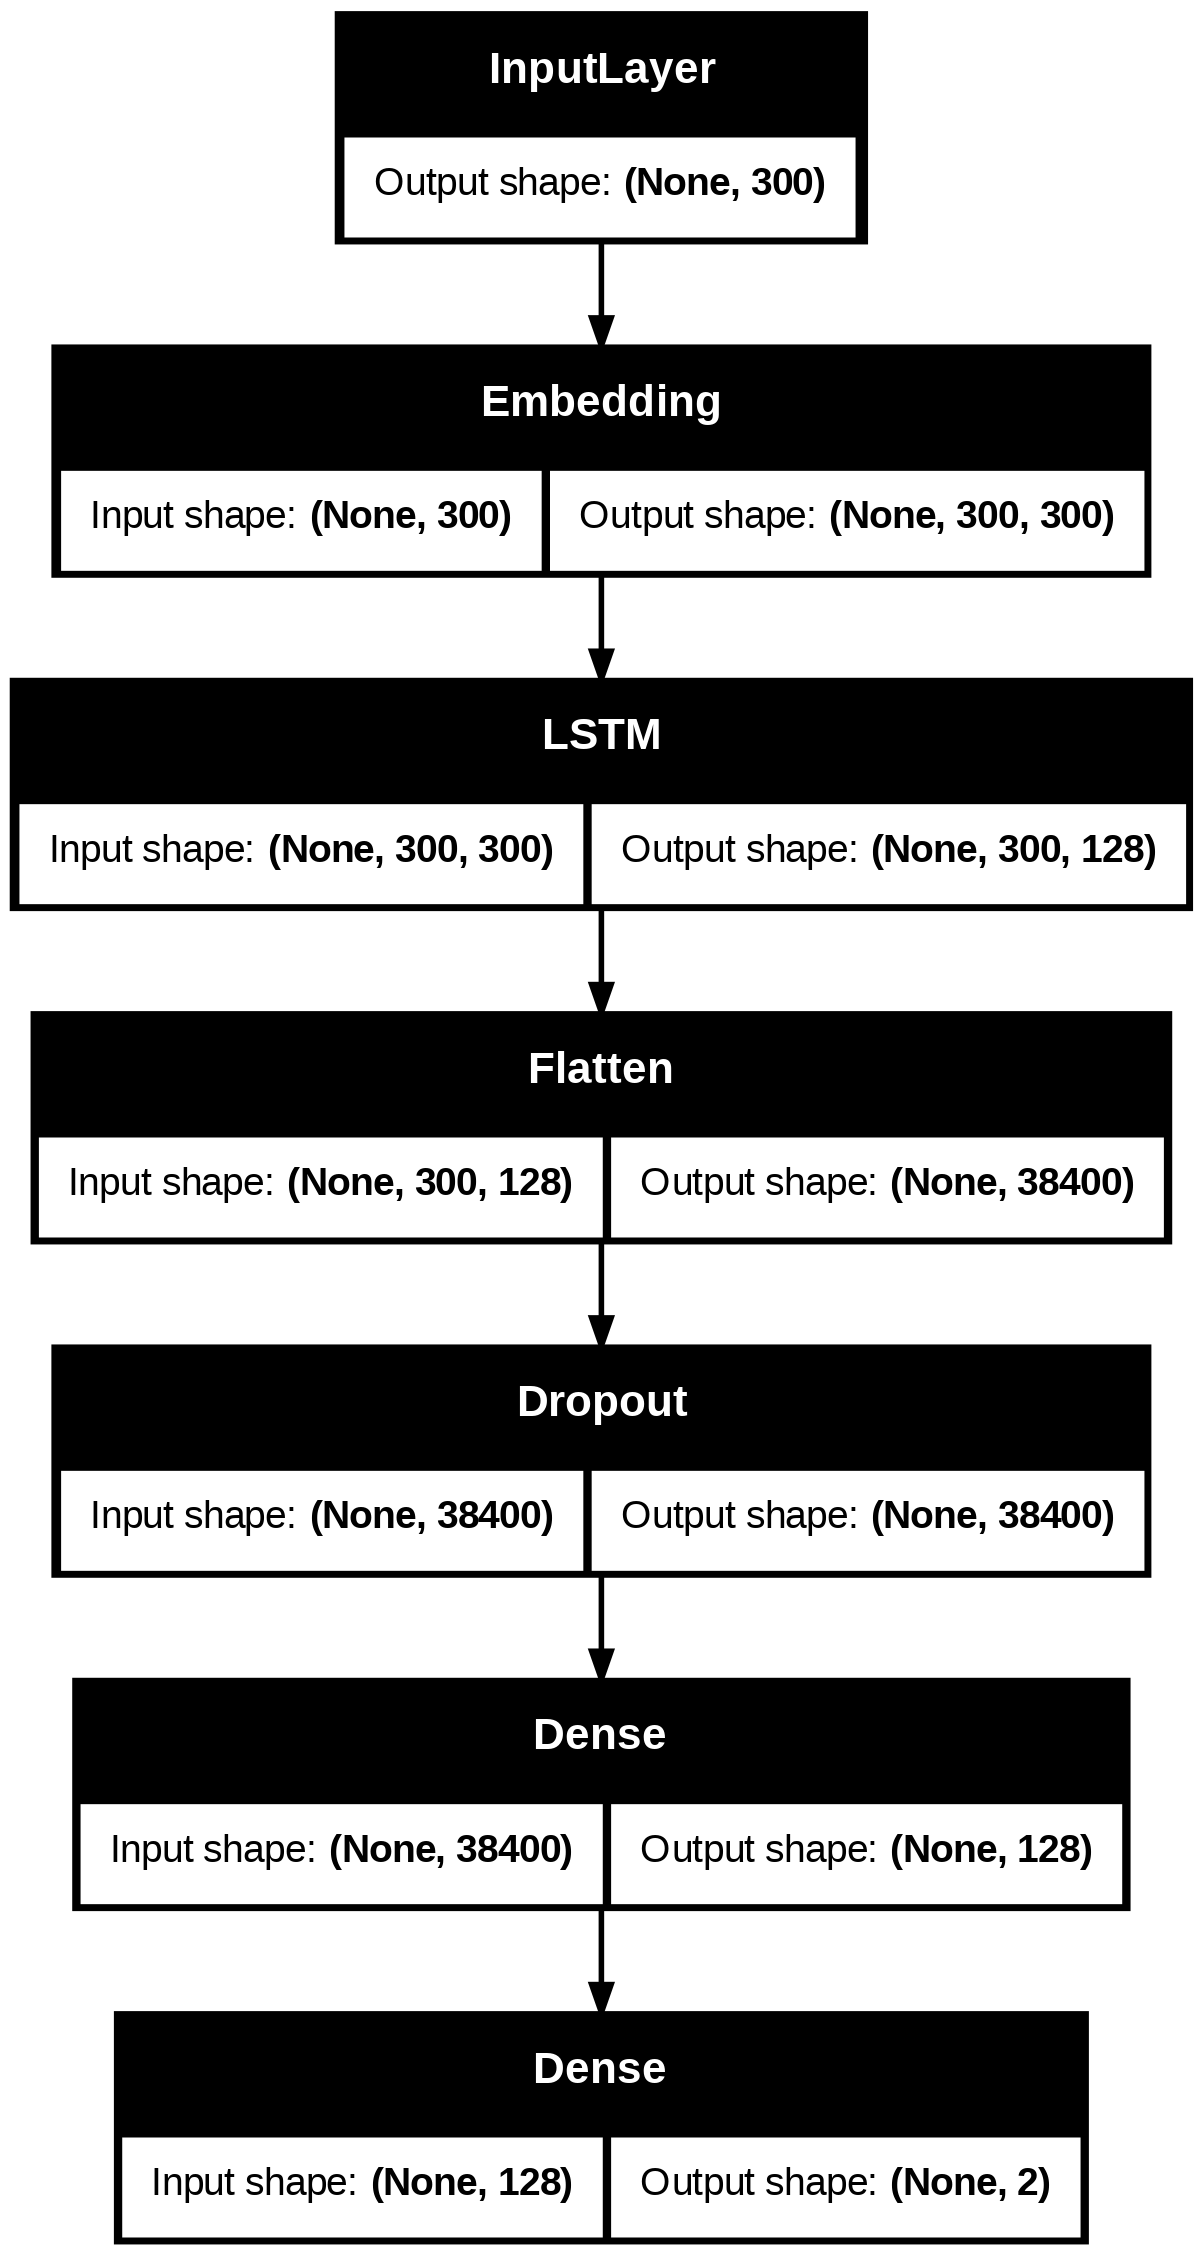

In [21]:
plot_model(model, show_shapes=True, to_file='singlelstm.png')
Image(filename="singlelstm.png")

Model training

Model training

In [22]:
model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [23]:
SLSTM_Model = model.fit(train_text,train_y,
              batch_size=BATCH_SIZE,
              epochs=NUM_EPOCHS,
              validation_data=(validate_text, validate_y))

Epoch 1/10


I0000 00:00:1779260856.393119     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


2821/2821 ━━━━━━━━━━━━━━━━━━━━ 314s 110ms/step - accuracy: 0.9295 - loss: 0.2445 - val_accuracy: 0.9416 - val_loss: 0.1635
Epoch 2/10
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 310s 110ms/step - accuracy: 0.9382 - loss: 0.1779 - val_accuracy: 0.9421 - val_loss: 0.1649
Epoch 3/10
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 310s 110ms/step - accuracy: 0.9393 - loss: 0.1732 - val_accuracy: 0.9454 - val_loss: 0.1539
Epoch 4/10
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 310s 110ms/step - accuracy: 0.9399 - loss: 0.1714 - val_accuracy: 0.9409 - val_loss: 0.1622
Epoch 5/10
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 310s 110ms/step - accuracy: 0.9413 - loss: 0.1676 - val_accuracy: 0.9458 - val_loss: 0.1509
Epoch 6/10
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 310s 110ms/step - accuracy: 0.9412 - loss: 0.1667 - val_accuracy: 0.9461 - val_loss: 0.1516
Epoch 7/10
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 309s 110ms/step - accuracy: 0.9417 - loss: 0.1654 - val_accuracy: 0.9448 - val_loss: 0.1510
Epoch 8/10
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 310s 110ms/step - accuracy: 0.9

Results

In [24]:
# Prediction on CV data
MODEL_NAME = 'slstm_model'
cv_df[MODEL_NAME] = model.predict(validate_text)[:, 1]

11281/11281 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step


In [25]:
bias_metrics_df = compute_bias_metrics_for_model(cv_df, identity_columns, MODEL_NAME, TOXICITY_COLUMN)
bias_metrics_df


Subgroup =  male

subgroup_negative_examples =  7585

non_subgroup_positive_examples =  27438

Subgroup =  male

subgroup_positive_examples =  1372

non_subgroup_negative_examples =  324580

Subgroup =  female

subgroup_negative_examples =  9268

non_subgroup_positive_examples =  27390

Subgroup =  female

subgroup_positive_examples =  1420

non_subgroup_negative_examples =  322897

Subgroup =  homosexual_gay_or_lesbian

subgroup_negative_examples =  1514

non_subgroup_positive_examples =  28214

Subgroup =  homosexual_gay_or_lesbian

subgroup_positive_examples =  596

non_subgroup_negative_examples =  330651

Subgroup =  christian

subgroup_negative_examples =  7271

non_subgroup_positive_examples =  28086

Subgroup =  christian

subgroup_positive_examples =  724

non_subgroup_negative_examples =  324894

Subgroup =  jewish

subgroup_negative_examples =  1286

non_subgroup_positive_examples =  28565

Subgroup =  jewish

subgroup_positive_examples =  245

non_subgroup_negative_example

,subgroup,subgroup_size,subgroup_auc,bpsn_auc,bnsp_auc
2,homosexual_gay_or_lesbian,2110,0.781405,0.772026,0.960848
7,white,4972,0.805828,0.742571,0.972464
6,black,3044,0.805839,0.756777,0.970501
5,muslim,4192,0.818466,0.831459,0.952196
4,jewish,1531,0.849751,0.846890,0.955800
8,psychiatric_or_mental_illness,988,0.888741,0.919167,0.931983
0,male,8957,0.896868,0.889480,0.955088
1,female,10688,0.900980,0.906953,0.948481
3,christian,7995,0.902054,0.926581,0.933379


In [26]:
get_final_metric(bias_metrics_df, calculate_overall_auc(cv_df, MODEL_NAME))

np.float64(0.8926956354834218)

In [27]:
model.save('/kaggle/working/SingleLSTM_Model.keras')

Bidirectional LSTM with sample weights

Model building

In [28]:
input_text_blstm = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='float32')
embedding_layer_blstm = Embedding(len(tokenizer.word_index) + 1,
                                    300,
                                    weights=[embedding_matrix],
                                    input_length=MAX_SEQUENCE_LENGTH,
                                    trainable=False)
b = embedding_layer_blstm(input_text_blstm)
b = SpatialDropout1D(0.2)(b)
b = Bidirectional(LSTM(128, return_sequences=True))(b)
b = Bidirectional(LSTM(128, return_sequences=True))(b)
b = GlobalMaxPooling1D()(b)
b = Dense(512, activation='relu')(b)
b = Dense(512, activation='relu')(b)
blstm_output = Dense(2, activation='softmax')(b)

In [29]:
model = Model(inputs=[input_text_blstm], outputs=[blstm_output])

Model visualization

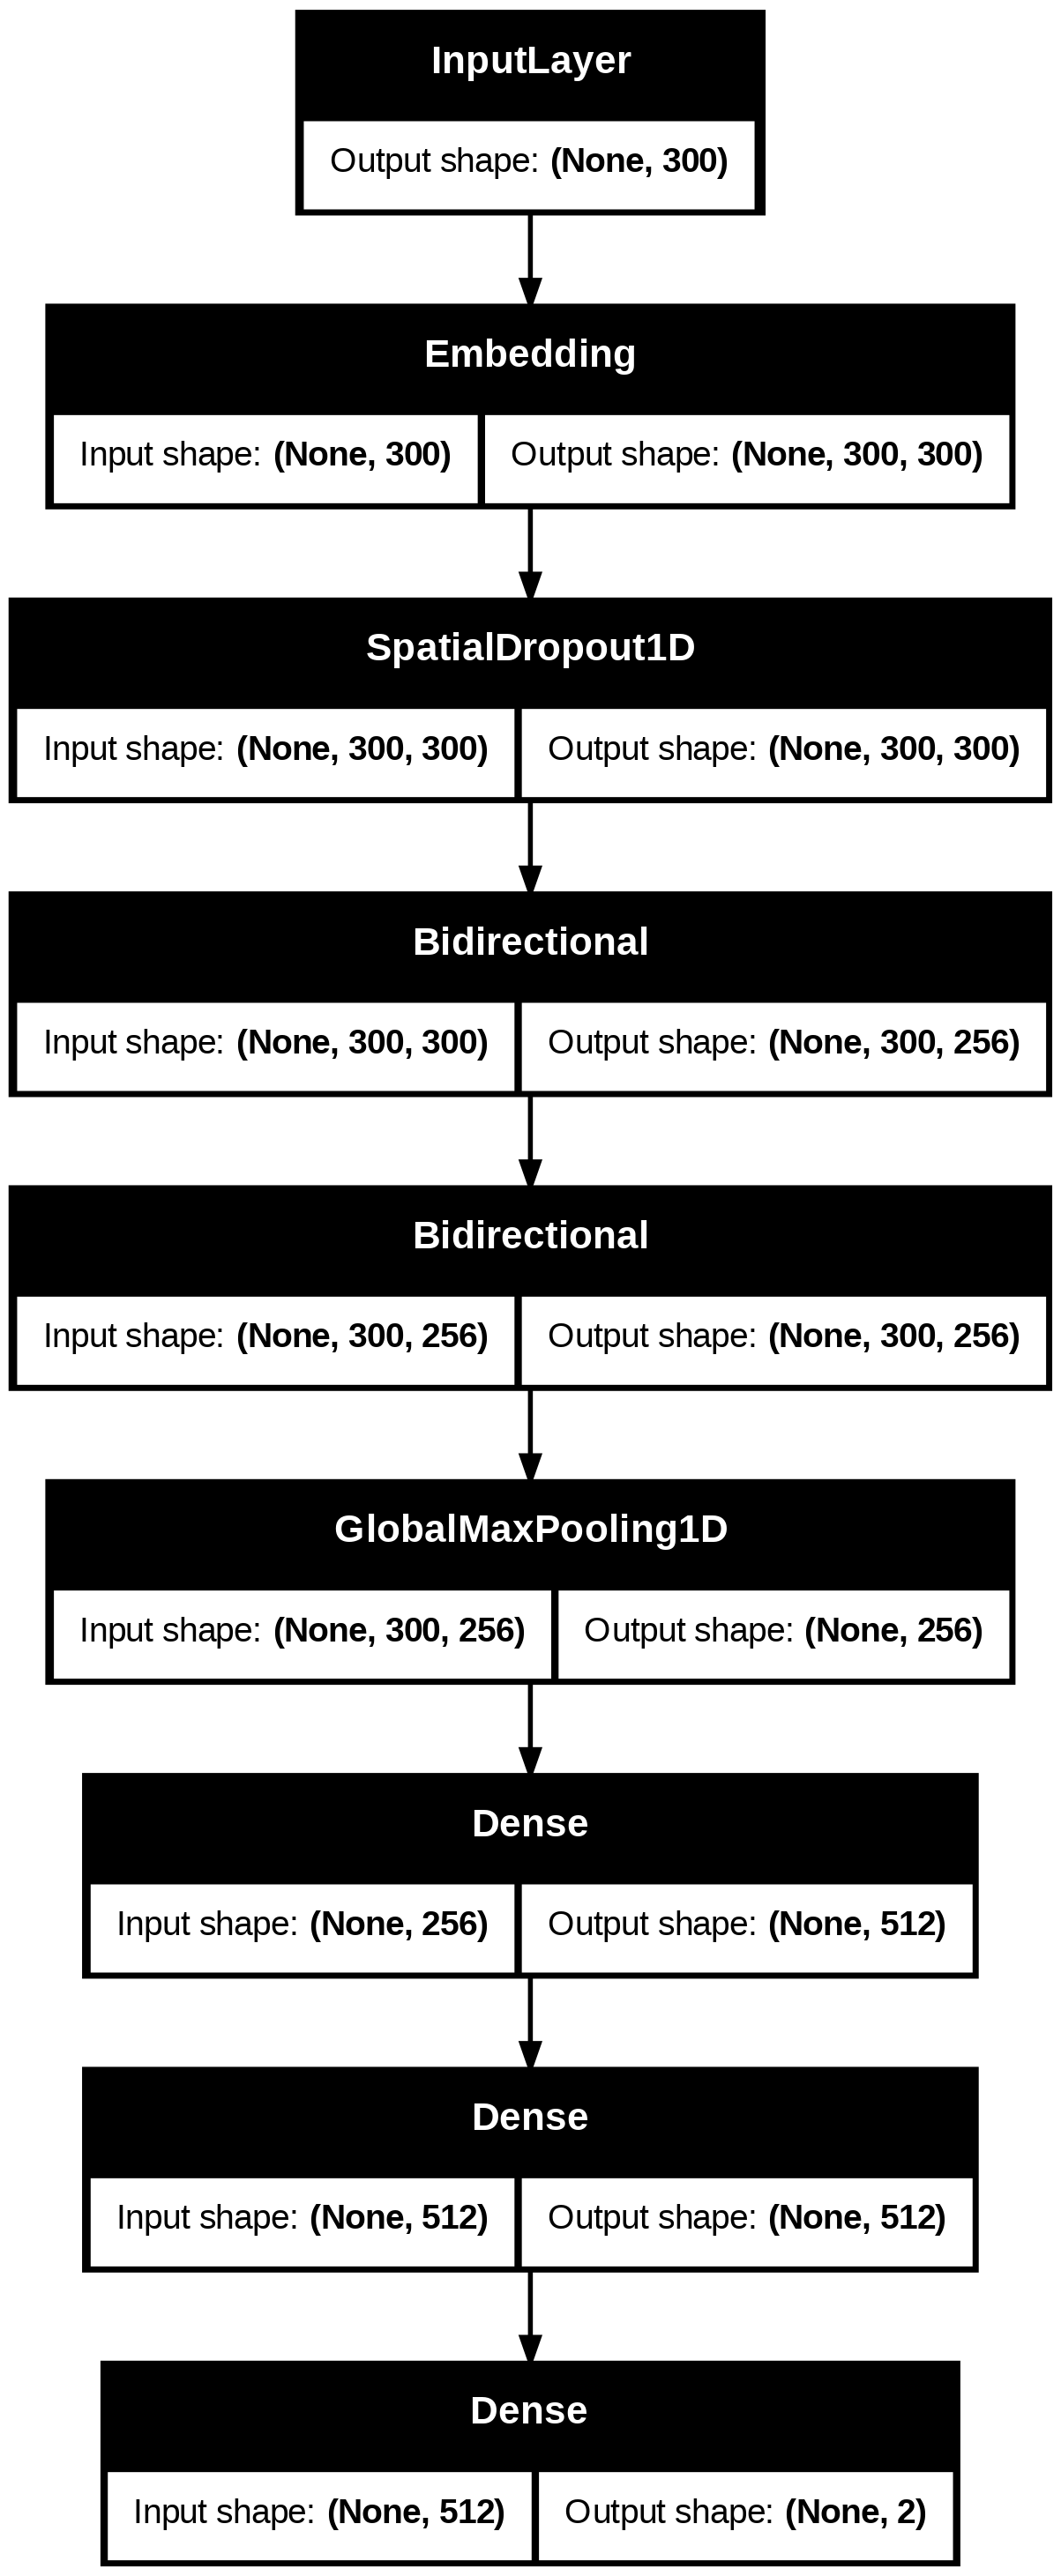

In [30]:
plot_model(model, show_shapes=True, to_file='blstm.png')
Image(filename="blstm.png")

Defining sample weights for training


In [31]:
sample_weights = np.ones(len(train_text), dtype=np.float32)
sample_weights += train_df[identity_columns].sum(axis=1) * 3
sample_weights += train_df[TOXICITY_COLUMN] * (~train_df[identity_columns]).sum(axis=1) * 3
sample_weights += (~train_df[TOXICITY_COLUMN]) * train_df[identity_columns].sum(axis=1) * 9
sample_weights /= sample_weights.mean()

In [32]:
[sample_weights.values, np.ones_like(sample_weights)]

[array([0.22835355, 0.22835355, 0.22835355, ..., 0.22835355, 0.22835355,
        0.22835355]),
 array([1., 1., 1., ..., 1., 1., 1.])]

Model training

In [33]:
model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [34]:
NUM_EPOCHS = 1

In [35]:
BLSTM_Model = model.fit(train_text,train_y,
              batch_size=BATCH_SIZE,
              epochs=NUM_EPOCHS,
              validation_data=(validate_text, validate_y),
              sample_weight = [sample_weights.values])

2821/2821 ━━━━━━━━━━━━━━━━━━━━ 1255s 444ms/step - accuracy: 0.7956 - loss: 0.3481 - val_accuracy: 0.8114 - val_loss: 0.3976


Results

In [36]:
MODEL_NAME = 'blstm_model'
cv_df[MODEL_NAME] = model.predict(validate_text)[:, 1]
     

bias_metrics_df = compute_bias_metrics_for_model(cv_df, identity_columns, MODEL_NAME, TOXICITY_COLUMN)
bias_metrics_df

11281/11281 ━━━━━━━━━━━━━━━━━━━━ 213s 19ms/step

Subgroup =  male

subgroup_negative_examples =  7585

non_subgroup_positive_examples =  27438

Subgroup =  male

subgroup_positive_examples =  1372

non_subgroup_negative_examples =  324580

Subgroup =  female

subgroup_negative_examples =  9268

non_subgroup_positive_examples =  27390

Subgroup =  female

subgroup_positive_examples =  1420

non_subgroup_negative_examples =  322897

Subgroup =  homosexual_gay_or_lesbian

subgroup_negative_examples =  1514

non_subgroup_positive_examples =  28214

Subgroup =  homosexual_gay_or_lesbian

subgroup_positive_examples =  596

non_subgroup_negative_examples =  330651

Subgroup =  christian

subgroup_negative_examples =  7271

non_subgroup_positive_examples =  28086

Subgroup =  christian

subgroup_positive_examples =  724

non_subgroup_negative_examples =  324894

Subgroup =  jewish

subgroup_negative_examples =  1286

non_subgroup_positive_examples =  28565

Subgroup =  jewish

subgroup_positiv

,subgroup,subgroup_size,subgroup_auc,bpsn_auc,bnsp_auc
2,homosexual_gay_or_lesbian,2110,0.803300,0.941478,0.840701
7,white,4972,0.812021,0.948039,0.845082
6,black,3044,0.814845,0.942463,0.851982
5,muslim,4192,0.839152,0.953902,0.842566
4,jewish,1531,0.873060,0.966435,0.824231
8,psychiatric_or_mental_illness,988,0.896317,0.945182,0.893942
0,male,8957,0.897552,0.970780,0.847771
3,christian,7995,0.906947,0.980683,0.809214
1,female,10688,0.907253,0.976861,0.836116


In [37]:
get_final_metric(bias_metrics_df, calculate_overall_auc(cv_df, MODEL_NAME))

np.float64(0.8991725127348124)

In [38]:
model.save('/kaggle/working/BidirectionalLSTM_Model.keras')

Model training with weighted samples

In [39]:
WBLSTM_Model = model.fit(train_text,train_y,
              batch_size=BATCH_SIZE,
              epochs=NUM_EPOCHS,
              validation_data=(validate_text, validate_y),
              sample_weight = [sample_weights.values])

2821/2821 ━━━━━━━━━━━━━━━━━━━━ 1250s 443ms/step - accuracy: 0.8417 - loss: 0.2731 - val_accuracy: 0.8561 - val_loss: 0.3341


Results

In [40]:
# Prediction on CV data
MODEL_NAME = 'blstm_model_weighted'
cv_df[MODEL_NAME] = model.predict(validate_text)[:, 1]
     

bias_metrics_df = compute_bias_metrics_for_model(cv_df, identity_columns, MODEL_NAME, TOXICITY_COLUMN)
bias_metrics_df

11281/11281 ━━━━━━━━━━━━━━━━━━━━ 212s 19ms/step

Subgroup =  male

subgroup_negative_examples =  7585

non_subgroup_positive_examples =  27438

Subgroup =  male

subgroup_positive_examples =  1372

non_subgroup_negative_examples =  324580

Subgroup =  female

subgroup_negative_examples =  9268

non_subgroup_positive_examples =  27390

Subgroup =  female

subgroup_positive_examples =  1420

non_subgroup_negative_examples =  322897

Subgroup =  homosexual_gay_or_lesbian

subgroup_negative_examples =  1514

non_subgroup_positive_examples =  28214

Subgroup =  homosexual_gay_or_lesbian

subgroup_positive_examples =  596

non_subgroup_negative_examples =  330651

Subgroup =  christian

subgroup_negative_examples =  7271

non_subgroup_positive_examples =  28086

Subgroup =  christian

subgroup_positive_examples =  724

non_subgroup_negative_examples =  324894

Subgroup =  jewish

subgroup_negative_examples =  1286

non_subgroup_positive_examples =  28565

Subgroup =  jewish

subgroup_positiv

,subgroup,subgroup_size,subgroup_auc,bpsn_auc,bnsp_auc
2,homosexual_gay_or_lesbian,2110,0.820575,0.948464,0.847367
7,white,4972,0.821960,0.947209,0.860638
6,black,3044,0.830886,0.941562,0.870951
5,muslim,4192,0.844291,0.959837,0.844469
4,jewish,1531,0.880515,0.972694,0.824355
0,male,8957,0.906925,0.974075,0.855220
8,psychiatric_or_mental_illness,988,0.909260,0.959140,0.890149
3,christian,7995,0.913241,0.983649,0.812156
1,female,10688,0.914605,0.979088,0.845447


In [41]:
get_final_metric(bias_metrics_df, calculate_overall_auc(cv_df, MODEL_NAME))

np.float64(0.9056022953046183)

In [42]:
model.save('/kaggle/working/WeightedSamplesBidirectionalLSTM_Model.keras')

**Using GRU and CONV1D + Attention Layer**

In [25]:
import tensorflow as tf
class Attention(Layer):
    def __init__(self, step_dim,
                 W_regularizer=None, b_regularizer=None,
                 W_constraint=None, b_constraint=None,
                 bias=True, **kwargs):
        self.supports_masking = True
        self.init = initializers.get('glorot_uniform')

        self.W_regularizer = regularizers.get(W_regularizer)
        self.b_regularizer = regularizers.get(b_regularizer)

        self.W_constraint = constraints.get(W_constraint)
        self.b_constraint = constraints.get(b_constraint)

        self.bias = bias
        self.step_dim = step_dim
        self.features_dim = 0
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 3

        self.W = self.add_weight((input_shape[-1],),
                                 initializer=self.init,
                                 name='{}_W'.format(self.name),
                                 regularizer=self.W_regularizer,
                                 constraint=self.W_constraint)
        self.features_dim = input_shape[-1]

        if self.bias:
            self.b = self.add_weight((input_shape[1],),
                                     initializer='zero',
                                     name='{}_b'.format(self.name),
                                     regularizer=self.b_regularizer,
                                     constraint=self.b_constraint)
        else:
            self.b = None

        self.built = True

    def compute_mask(self, input, input_mask=None):
        return None

    def call(self, x, mask=None):
        features_dim = self.features_dim
        step_dim = self.step_dim
    
        # Replace K.reshape + K.dot with TensorFlow ops
        eij = tf.reshape(
            tf.matmul(
                tf.reshape(x, (-1, features_dim)),
                tf.reshape(self.W, (features_dim, 1))
            ),
            (-1, step_dim)
        )
    
        if self.bias:
            eij += self.b
    
        eij = tf.tanh(eij)
    
        a = tf.exp(eij)
    
        if mask is not None:
            a *= tf.cast(mask, tf.float32)
    
        a /= tf.cast(
            tf.reduce_sum(a, axis=1, keepdims=True) + K.epsilon(),
            tf.float32
        )
    
        a = tf.expand_dims(a, axis=-1)
    
        weighted_input = x * a
    
        return tf.reduce_sum(weighted_input, axis=1)

    def compute_output_shape(self, input_shape):
        return input_shape[0],  self.features_dim

Model building

In [26]:
input_text_bgru = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='float32')
embedding_layer_bgru = Embedding(len(tokenizer.word_index) + 1,
                                    300,
                                    weights=[embedding_matrix],
                                    input_length=MAX_SEQUENCE_LENGTH,
                                    trainable=False)
g = embedding_layer_bgru(input_text_bgru)
g = SpatialDropout1D(0.4)(g)
g = Bidirectional(GRU(64, return_sequences=True))(g)
att = Attention(MAX_SEQUENCE_LENGTH)(g)
g = Conv1D(64, kernel_size = 3, padding = "valid", kernel_initializer = "he_uniform")(g)
avg_pool1 = GlobalAveragePooling1D()(g)
max_pool1 = GlobalMaxPooling1D()(g)
g = concatenate([att,avg_pool1, max_pool1])
g = Dense(128, activation='relu')(g)
bgru_output = Dense(2, activation='softmax')(g)

In [27]:
model = Model(inputs=[input_text_bgru], outputs=[bgru_output])

Model visualization

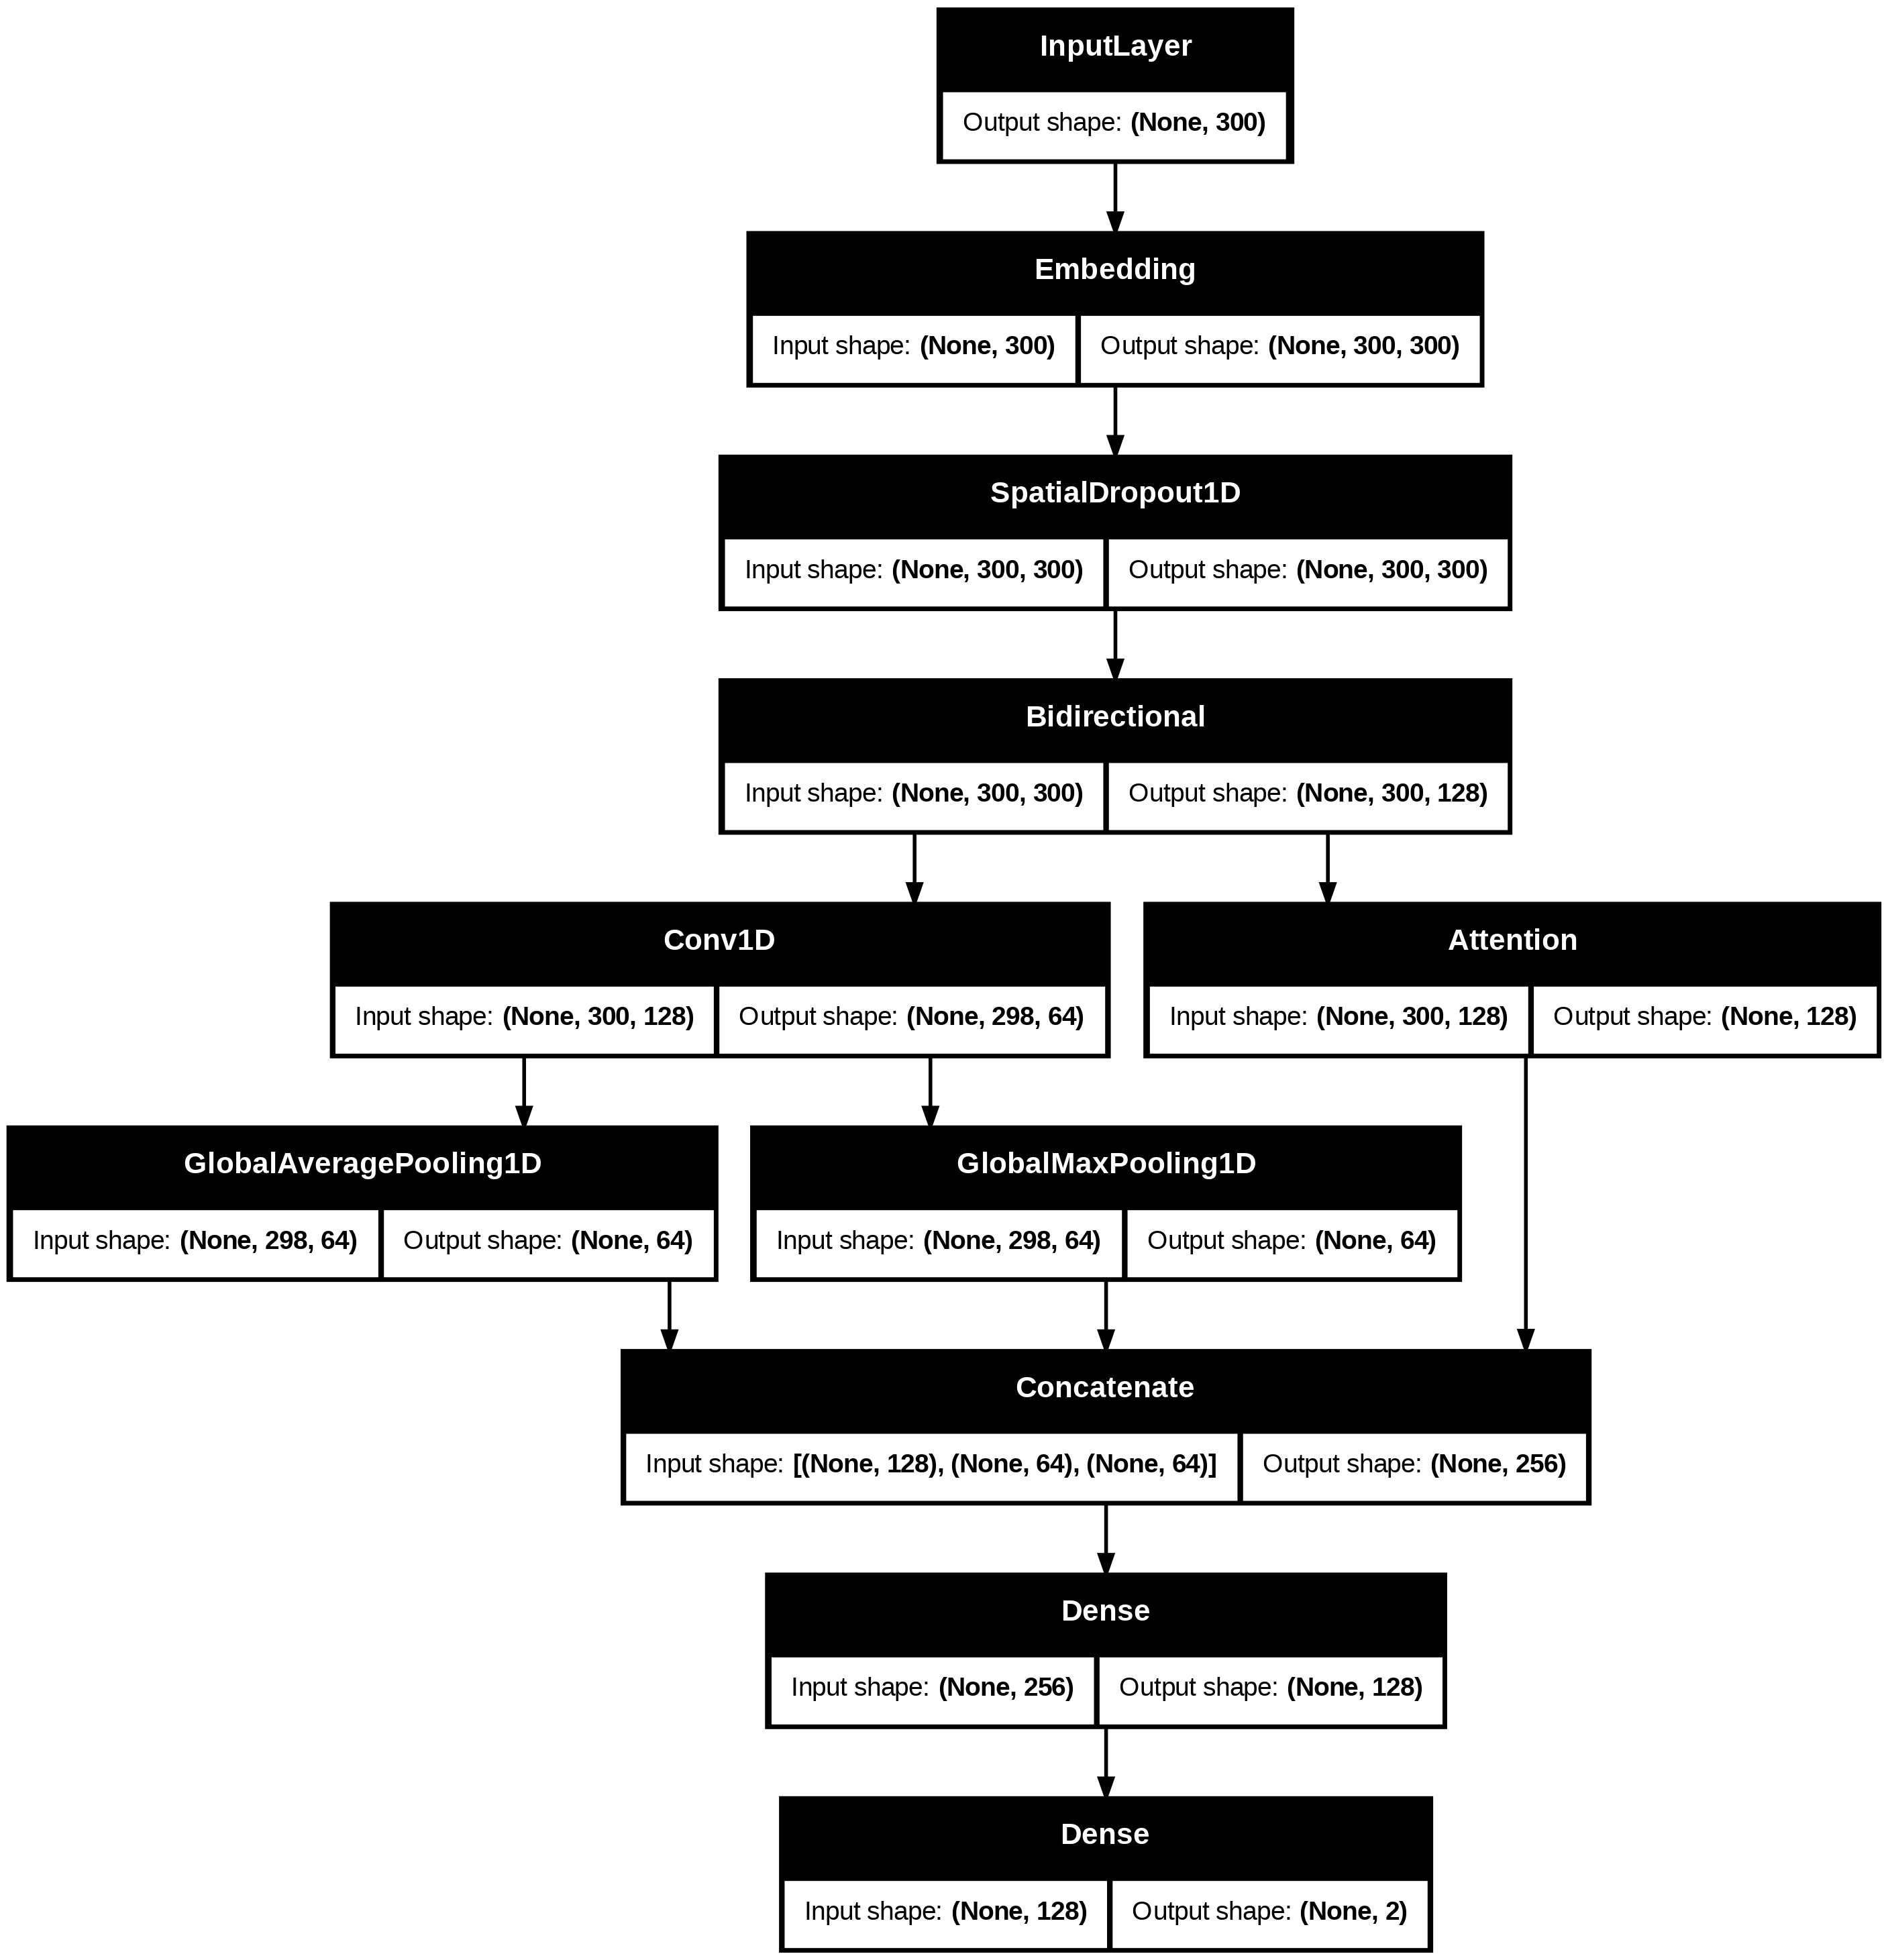

In [28]:
plot_model(model, show_shapes=True, to_file='bgru.png')
Image(filename="bgru.png")

Model training

In [29]:
model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [30]:
NUM_EPOCHS = 6
BATCH_SIZE = 1300
     

BGRU_Model = model.fit(train_text,train_y,
              batch_size=BATCH_SIZE,
              epochs=NUM_EPOCHS,
              validation_data=(validate_text, validate_y))

Epoch 1/6
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 364s 325ms/step - accuracy: 0.9342 - loss: 0.1897 - val_accuracy: 0.9490 - val_loss: 0.1288
Epoch 2/6
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 361s 325ms/step - accuracy: 0.9471 - loss: 0.1357 - val_accuracy: 0.9508 - val_loss: 0.1249
Epoch 3/6
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 360s 324ms/step - accuracy: 0.9490 - loss: 0.1295 - val_accuracy: 0.9507 - val_loss: 0.1228
Epoch 4/6
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 359s 324ms/step - accuracy: 0.9500 - loss: 0.1256 - val_accuracy: 0.9499 - val_loss: 0.1242
Epoch 5/6
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 360s 324ms/step - accuracy: 0.9507 - loss: 0.1237 - val_accuracy: 0.9514 - val_loss: 0.1212
Epoch 6/6
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 360s 324ms/step - accuracy: 0.9514 - loss: 0.1217 - val_accuracy: 0.9499 - val_loss: 0.1230


Results

In [31]:
temp_df = cv_df[:30000]
     

# Prediction on CV data
MODEL_NAME = 'bgru_model'
cv_df[MODEL_NAME] = model.predict(validate_text)[:, 1]
     

bias_metrics_df = compute_bias_metrics_for_model(cv_df, identity_columns, MODEL_NAME, TOXICITY_COLUMN)
bias_metrics_df

11281/11281 ━━━━━━━━━━━━━━━━━━━━ 99s 9ms/step

Subgroup =  male

subgroup_negative_examples =  7585

non_subgroup_positive_examples =  27438

Subgroup =  male

subgroup_positive_examples =  1372

non_subgroup_negative_examples =  324580

Subgroup =  female

subgroup_negative_examples =  9268

non_subgroup_positive_examples =  27390

Subgroup =  female

subgroup_positive_examples =  1420

non_subgroup_negative_examples =  322897

Subgroup =  homosexual_gay_or_lesbian

subgroup_negative_examples =  1514

non_subgroup_positive_examples =  28214

Subgroup =  homosexual_gay_or_lesbian

subgroup_positive_examples =  596

non_subgroup_negative_examples =  330651

Subgroup =  christian

subgroup_negative_examples =  7271

non_subgroup_positive_examples =  28086

Subgroup =  christian

subgroup_positive_examples =  724

non_subgroup_negative_examples =  324894

Subgroup =  jewish

subgroup_negative_examples =  1286

non_subgroup_positive_examples =  28565

Subgroup =  jewish

subgroup_positive_

,subgroup,subgroup_size,subgroup_auc,bpsn_auc,bnsp_auc
2,homosexual_gay_or_lesbian,2110,0.831983,0.803663,0.975691
7,white,4972,0.837417,0.827843,0.971667
6,black,3044,0.842358,0.814836,0.975645
5,muslim,4192,0.859602,0.863046,0.966757
4,jewish,1531,0.876510,0.904167,0.955202
8,psychiatric_or_mental_illness,988,0.921209,0.905326,0.970497
3,christian,7995,0.921983,0.944990,0.949503
0,male,8957,0.922125,0.914341,0.968579
1,female,10688,0.924380,0.923871,0.965368


In [32]:
get_final_metric(bias_metrics_df, calculate_overall_auc(cv_df, MODEL_NAME))

np.float64(0.9189791293908811)

In [33]:
model.save('/kaggle/working/GRU_CONV1D_Model.keras')

More dense architecture

In [19]:
input_text_bgru = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='float32')
embedding_layer_bgru = Embedding(len(tokenizer.word_index) + 1,
                                    300,
                                    weights=[embedding_matrix],
                                    input_length=MAX_SEQUENCE_LENGTH,
                                    trainable=False)
g = embedding_layer_bgru(input_text_bgru)
g = SpatialDropout1D(0.4)(g)
g = Bidirectional(GRU(128, return_sequences=True))(g)
g = Conv1D(64, kernel_size = 3, padding = "valid", kernel_initializer = "he_uniform")(g)
avg_pool1 = GlobalAveragePooling1D()(g)
max_pool1 = GlobalMaxPooling1D()(g)
g = concatenate([avg_pool1, max_pool1])
#g = Dense(128, activation='relu')(g)
bgru_output = Dense(2, activation='softmax')(g)

I0000 00:00:1779272771.731330      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779272771.737433      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [20]:
model = Model(inputs=[input_text_bgru], outputs=[bgru_output])
     

model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [21]:
NUM_EPOCHS = 5
BATCH_SIZE = 1024
     

BGRU_Model = model.fit(train_text,train_y,
              batch_size=BATCH_SIZE,
              epochs=NUM_EPOCHS,
              validation_data=(validate_text, validate_y))

Epoch 1/5


I0000 00:00:1779272780.443838     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


1411/1411 ━━━━━━━━━━━━━━━━━━━━ 578s 405ms/step - accuracy: 0.9373 - loss: 0.1752 - val_accuracy: 0.9491 - val_loss: 0.1295
Epoch 2/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 580s 411ms/step - accuracy: 0.9472 - loss: 0.1351 - val_accuracy: 0.9517 - val_loss: 0.1221
Epoch 3/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 579s 411ms/step - accuracy: 0.9499 - loss: 0.1279 - val_accuracy: 0.9494 - val_loss: 0.1245
Epoch 4/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 580s 411ms/step - accuracy: 0.9508 - loss: 0.1243 - val_accuracy: 0.9495 - val_loss: 0.1242
Epoch 5/5
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 580s 411ms/step - accuracy: 0.9518 - loss: 0.1217 - val_accuracy: 0.9421 - val_loss: 0.1373


In [22]:
# Prediction on CV data
MODEL_NAME = 'bgru_model'
cv_df[MODEL_NAME] = model.predict(validate_text)[:, 1]
     

bias_metrics_df = compute_bias_metrics_for_model(cv_df, identity_columns, MODEL_NAME, TOXICITY_COLUMN)
bias_metrics_df

11281/11281 ━━━━━━━━━━━━━━━━━━━━ 112s 10ms/step

Subgroup =  male

subgroup_negative_examples =  7585

non_subgroup_positive_examples =  27438

Subgroup =  male

subgroup_positive_examples =  1372

non_subgroup_negative_examples =  324580

Subgroup =  female

subgroup_negative_examples =  9268

non_subgroup_positive_examples =  27390

Subgroup =  female

subgroup_positive_examples =  1420

non_subgroup_negative_examples =  322897

Subgroup =  homosexual_gay_or_lesbian

subgroup_negative_examples =  1514

non_subgroup_positive_examples =  28214

Subgroup =  homosexual_gay_or_lesbian

subgroup_positive_examples =  596

non_subgroup_negative_examples =  330651

Subgroup =  christian

subgroup_negative_examples =  7271

non_subgroup_positive_examples =  28086

Subgroup =  christian

subgroup_positive_examples =  724

non_subgroup_negative_examples =  324894

Subgroup =  jewish

subgroup_negative_examples =  1286

non_subgroup_positive_examples =  28565

Subgroup =  jewish

subgroup_positiv

,subgroup,subgroup_size,subgroup_auc,bpsn_auc,bnsp_auc
2,homosexual_gay_or_lesbian,2110,0.827451,0.812828,0.972979
6,black,3044,0.838493,0.790724,0.979206
7,white,4972,0.839099,0.808296,0.976011
5,muslim,4192,0.860592,0.883755,0.960011
4,jewish,1531,0.882531,0.913116,0.952449
0,male,8957,0.921052,0.914337,0.968437
8,psychiatric_or_mental_illness,988,0.922045,0.899296,0.972954
1,female,10688,0.925243,0.925222,0.965067
3,christian,7995,0.925302,0.949421,0.947345


In [23]:
get_final_metric(bias_metrics_df, calculate_overall_auc(cv_df, MODEL_NAME))

np.float64(0.9180755600539561)

In [24]:
model.save('/kaggle/working/DenseGRU_CONV1D_Model.keras')